# Bangla News Classification: Political vs Non-Political

This notebook implements a binary text classification model to identify political news articles in Bangla using BanglaBERT.

**Pipeline:**
1. **Setup & Installation** - Install required dependencies
2. **Data Loading & EDA** - Load data and perform exploratory analysis
3. **Pre-processing** - Tokenization and dataset preparation
4. **Training** - Model training with different configurations
5. **Validation & Evaluation** - Performance metrics and analysis
6. **Hyperparameter Experiments** - Testing different configurations
7. **Inference** - Making predictions on new data

## 1. Setup & Installation

In [3]:
!pip install -U transformers datasets evaluate accelerate sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 19.8 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pylibcudf-cu12 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.
cudf-cu12 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompati

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Import All Required Libraries

In [1]:
# Core libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML & Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Hugging Face Transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)
from datasets import Dataset, DatasetDict, load_from_disk
import evaluate

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# Define the path to your CSV
csv_path = '/content/drive/MyDrive/potrika dataset/potrika_for_binary_politics.csv'

# Load the CSV into a pandas DataFrame
df = pd.read_csv(csv_path)

# Show basic info
print("✅ Dataset loaded successfully!")
print(f"Total rows: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"\nDataset shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")

# Display first few rows
display(df.head())

✅ Dataset loaded successfully!
Total rows: 50062
Columns: ['text', 'label', 'category']

Dataset shape: (50062, 3)

Missing values:
text        0
label       0
category    0
dtype: int64


,text,label,category
0,অন্য করো বর্ধিত সভা ডাকার কোনো বৈধ্যতা নেই বলে...,1,Politics
1,বিএনপি চেয়ারপারসন বেগম খালেদা জিয়া ১৯ শে মার...,1,Politics
2,জার্মানির অসবার্গে সম্প্রতি সন্ধান পাওয়া দ্বি...,0,International
3,প্রাকৃতিক গ্যাস সম্পদের কারণেই ভোলা বাংলাদেশের...,1,Politics
4,আইনমন্ত্রী আনিসুল হক বলেছেন বর্তমান সরকারের আম...,1,Politics


## 2. Data Loading & Exploratory Data Analysis (EDA)

### Class Distribution Analysis

📊 Class Distribution:
Class 0 (Non-Political): 9923 (19.82%)
Class 1 (Political): 40139 (80.18%)

Class imbalance ratio: 4.05:1


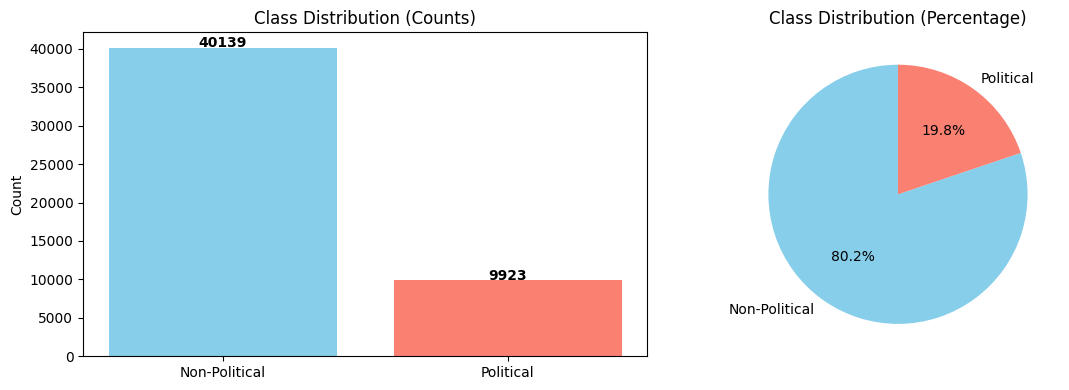

In [3]:
# Analyze class distribution
df['label'] = df['label'].astype(int)
label_counts = df['label'].value_counts()
label_percentages = df['label'].value_counts(normalize=True) * 100

print("📊 Class Distribution:")
print(f"Class 0 (Non-Political): {label_counts[0]} ({label_percentages[0]:.2f}%)")
print(f"Class 1 (Political): {label_counts[1]} ({label_percentages[1]:.2f}%)")
print(f"\nClass imbalance ratio: {label_counts.max() / label_counts.min():.2f}:1")

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
axes[0].bar(['Non-Political', 'Political'], label_counts.values, color=['skyblue', 'salmon'])
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution (Counts)')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(label_counts.values, labels=['Non-Political', 'Political'],
            autopct='%1.1f%%', colors=['skyblue', 'salmon'], startangle=90)
axes[1].set_title('Class Distribution (Percentage)')

plt.tight_layout()
plt.show()

### Balance Dataset by Sampling from Categories

The dataset is highly imbalanced (80% Political, 20% Non-Political). We'll balance it by:
1. Keeping all Political articles
2. Upsampling Non-Political articles by sampling evenly from each category

📊 Original Dataset Statistics:
Total samples: 50062

Class distribution:
label
1    40139
0     9923
Name: count, dtype: int64

Class percentages:
label
1    80.178579
0    19.821421
Name: proportion, dtype: float64

Political samples: 40139
Non-Political samples: 9923

Non-Political categories distribution:
category
National             1480
ScienceTechnology    1457
Sports               1452
International        1401
Economy              1390
Education            1383
Entertainment        1360
Name: count, dtype: int64

Total unique categories: 7

🎯 Balancing Strategy:
Target non-political samples: 40139
Non-political categories: 7
Samples per category: 5734
Remainder to distribute: 1

✓ International: sampled 5735 (original: 1401, with replacement)
✓ National: sampled 5734 (original: 1480, with replacement)
✓ Sports: sampled 5734 (original: 1452, with replacement)
✓ Education: sampled 5734 (original: 1383, with replacement)
✓ Economy: sampled 5734 (original: 1390, with replacement)


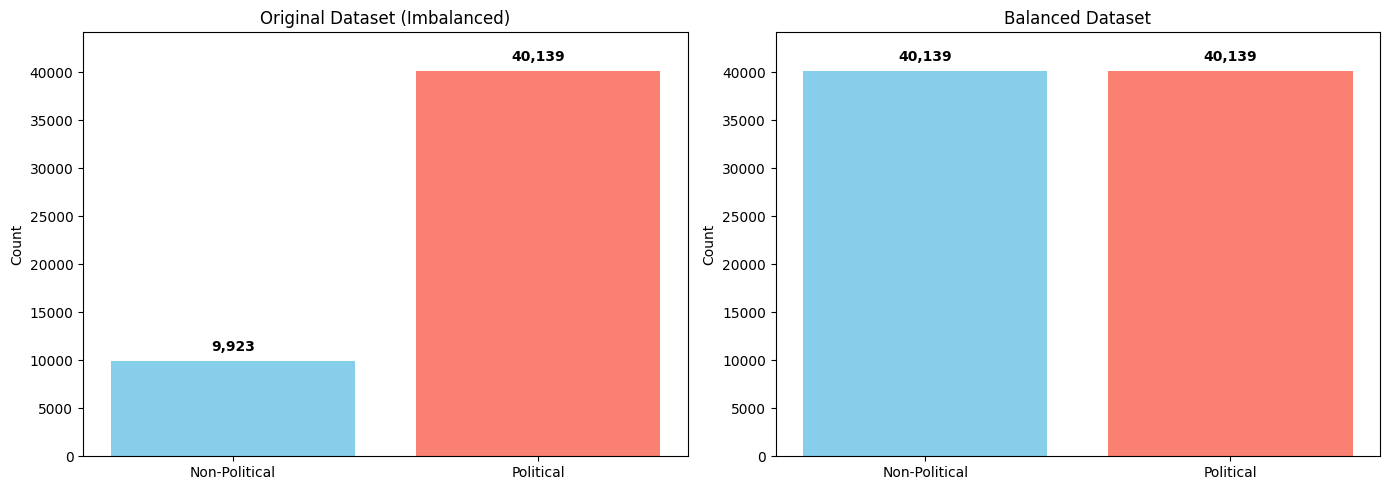


✅ Updated main dataframe 'df' with balanced data


In [5]:
# Load the original dataset
df_original = pd.read_csv(csv_path)
df_original['label'] = df_original['label'].astype(int)

print("📊 Original Dataset Statistics:")
print(f"Total samples: {len(df_original)}")
print(f"\nClass distribution:")
print(df_original['label'].value_counts())
print(f"\nClass percentages:")
print(df_original['label'].value_counts(normalize=True) * 100)

# Separate political and non-political data
df_political = df_original[df_original['label'] == 1].copy()
df_non_political = df_original[df_original['label'] == 0].copy()

print(f"\n{'='*80}")
print(f"Political samples: {len(df_political)}")
print(f"Non-Political samples: {len(df_non_political)}")

# Check non-political categories
if 'category' in df_non_political.columns:
    print(f"\nNon-Political categories distribution:")
    category_counts = df_non_political['category'].value_counts()
    print(category_counts)
    print(f"\nTotal unique categories: {df_non_political['category'].nunique()}")
else:
    print("\n⚠️  Warning: 'category' column not found in dataset")

# Strategy: Upsample non-political to match political count
# Sample evenly from each non-political category
target_non_political_count = len(df_political)  # Match political count for balance

if 'category' in df_non_political.columns:
    # Get all unique non-political categories
    non_political_categories = df_non_political['category'].unique()
    samples_per_category = target_non_political_count // len(non_political_categories)
    remainder = target_non_political_count % len(non_political_categories)

    print(f"\n{'='*80}")
    print(f"🎯 Balancing Strategy:")
    print(f"Target non-political samples: {target_non_political_count}")
    print(f"Non-political categories: {len(non_political_categories)}")
    print(f"Samples per category: {samples_per_category}")
    print(f"Remainder to distribute: {remainder}")
    print(f"{'='*80}\n")

    # Sample from each category
    balanced_non_political_dfs = []

    for i, category in enumerate(non_political_categories):
        category_df = df_non_political[df_non_political['category'] == category]

        # Add one extra sample to first few categories to handle remainder
        n_samples = samples_per_category + (1 if i < remainder else 0)

        # If category has fewer samples than needed, sample with replacement
        replace = len(category_df) < n_samples

        sampled = category_df.sample(n=n_samples, replace=replace, random_state=RANDOM_SEED)
        balanced_non_political_dfs.append(sampled)

        print(f"✓ {category}: sampled {n_samples} (original: {len(category_df)}, "
              f"{'with replacement' if replace else 'without replacement'})")

    # Combine all sampled non-political data
    df_non_political_balanced = pd.concat(balanced_non_political_dfs, ignore_index=True)

else:
    # If no category column, just upsample the entire non-political data
    print(f"\n⚠️  No category column found. Upsampling entire non-political data...")
    df_non_political_balanced = df_non_political.sample(
        n=target_non_political_count,
        replace=True,
        random_state=RANDOM_SEED
    )

# Combine political and balanced non-political data
df_balanced = pd.concat([df_political, df_non_political_balanced], ignore_index=True)

# Shuffle the balanced dataset
df_balanced = df_balanced.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

print(f"\n{'='*80}")
print(f"✅ Dataset Balanced Successfully!")
print(f"{'='*80}")
print(f"\n📊 Balanced Dataset Statistics:")
print(f"Total samples: {len(df_balanced)}")
print(f"\nClass distribution:")
print(df_balanced['label'].value_counts())
print(f"\nClass percentages:")
print(df_balanced['label'].value_counts(normalize=True) * 100)

if 'category' in df_balanced.columns:
    print(f"\nCategory distribution in balanced dataset:")
    print(df_balanced.groupby(['label', 'category']).size().unstack(fill_value=0))

# Visualize the balancing
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before balancing
axes[0].bar(['Non-Political', 'Political'],
            [len(df_non_political), len(df_political)],
            color=['skyblue', 'salmon'])
axes[0].set_ylabel('Count')
axes[0].set_title('Original Dataset (Imbalanced)')
axes[0].set_ylim(0, max(len(df_political), len(df_non_political)) * 1.1)
for i, v in enumerate([len(df_non_political), len(df_political)]):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# After balancing
balanced_counts = df_balanced['label'].value_counts().sort_index()
axes[1].bar(['Non-Political', 'Political'],
            balanced_counts.values,
            color=['skyblue', 'salmon'])
axes[1].set_ylabel('Count')
axes[1].set_title('Balanced Dataset')
axes[1].set_ylim(0, max(balanced_counts.values) * 1.1)
for i, v in enumerate(balanced_counts.values):
    axes[1].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Update the main dataframe to use balanced version
df = df_balanced.copy()
print(f"\n✅ Updated main dataframe 'df' with balanced data")

## Text length Statistics

📏 Text Length Statistics:

Character count statistics:
         count         mean          std    min    25%     50%     75%  \
label                                                                    
0      40139.0  1434.039363  1072.892155    8.0  794.0  1165.0  1710.0   
1      40139.0  1423.607638   990.650253  101.0  939.0  1307.0  1471.0   

           max  
label           
0      18302.0  
1      50056.0  

Word count statistics:
         count        mean         std   min    25%    50%    75%     max
label                                                                    
0      40139.0  213.398191  162.820739   2.0  117.0  172.0  252.0  2752.0
1      40139.0  207.687685  147.522601  13.0  136.0  189.0  217.0  7046.0


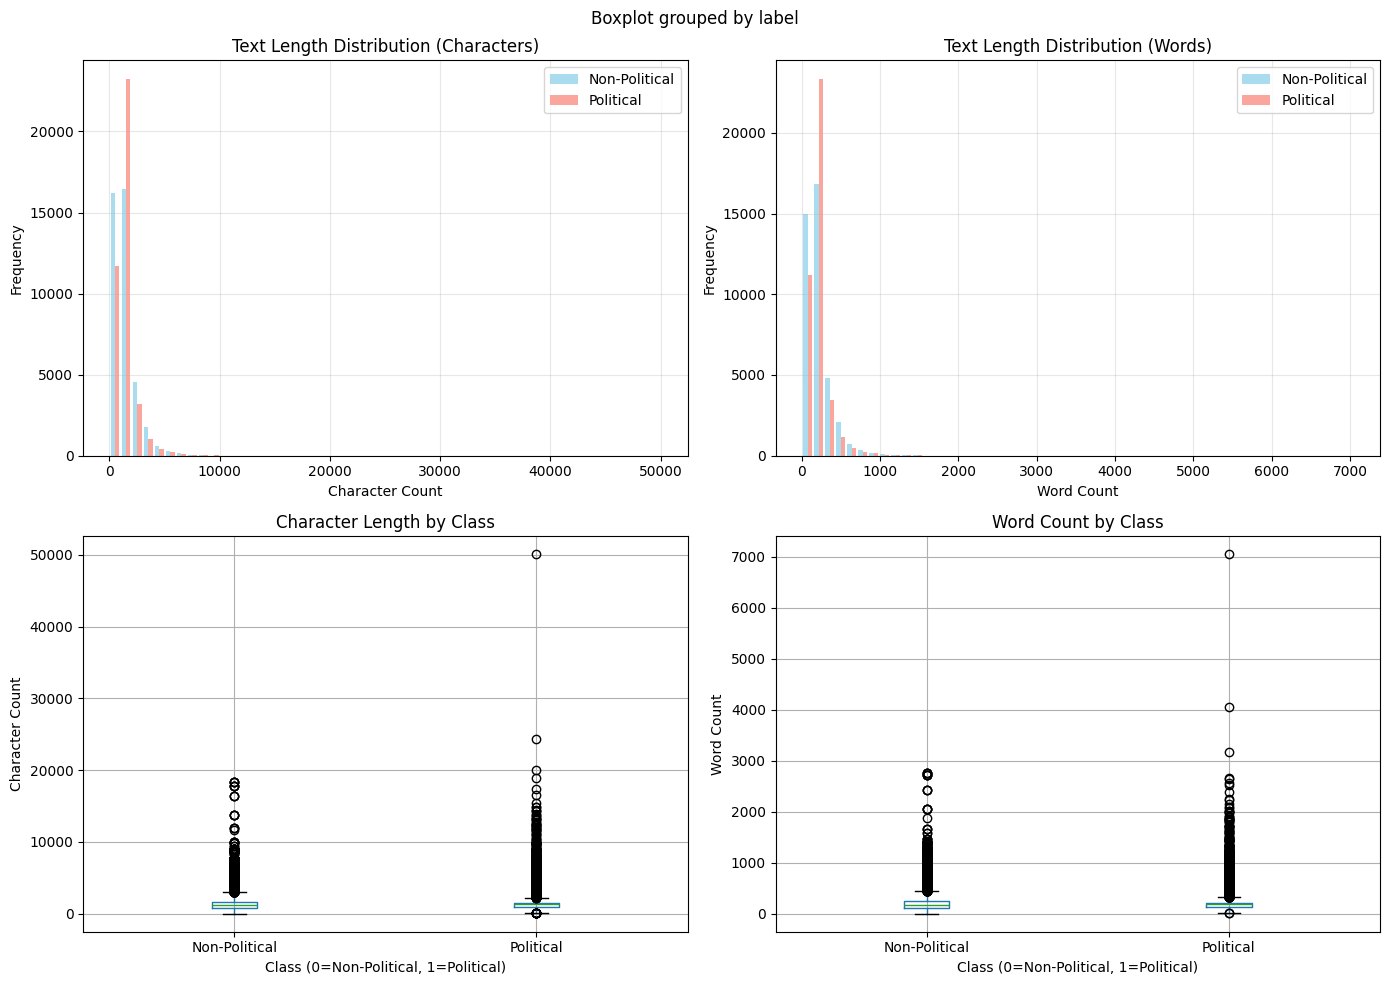

In [6]:
# Calculate text lengths
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

print("📏 Text Length Statistics:")
print(f"\nCharacter count statistics:")
print(df.groupby('label')['text_length'].describe())
print(f"\nWord count statistics:")
print(df.groupby('label')['word_count'].describe())

# Visualize text lengths
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Character length distribution
axes[0, 0].hist([df[df['label']==0]['text_length'], df[df['label']==1]['text_length']],
                bins=50, label=['Non-Political', 'Political'], color=['skyblue', 'salmon'], alpha=0.7)
axes[0, 0].set_xlabel('Character Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Text Length Distribution (Characters)')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Word count distribution
axes[0, 1].hist([df[df['label']==0]['word_count'], df[df['label']==1]['word_count']],
                bins=50, label=['Non-Political', 'Political'], color=['skyblue', 'salmon'], alpha=0.7)
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Text Length Distribution (Words)')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Box plot for character length
df.boxplot(column='text_length', by='label', ax=axes[1, 0])
axes[1, 0].set_xlabel('Class (0=Non-Political, 1=Political)')
axes[1, 0].set_ylabel('Character Count')
axes[1, 0].set_title('Character Length by Class')
plt.sca(axes[1, 0])
plt.xticks([1, 2], ['Non-Political', 'Political'])

# Box plot for word count
df.boxplot(column='word_count', by='label', ax=axes[1, 1])
axes[1, 1].set_xlabel('Class (0=Non-Political, 1=Political)')
axes[1, 1].set_ylabel('Word Count')
axes[1, 1].set_title('Word Count by Class')
plt.sca(axes[1, 1])
plt.xticks([1, 2], ['Non-Political', 'Political'])

plt.tight_layout()
plt.show()

## 3. Data Pre-processing & Tokenization

### Configuration & Paths

In [7]:
# Paths & settings
csv_path = '/content/drive/MyDrive/potrika dataset/potrika_for_binary_politics.csv'
OUT_DIR = '/content/drive/MyDrive/potrika dataset/tokenized_dataset'
os.makedirs(OUT_DIR, exist_ok=True)

MODEL_NAME = "csebuetnlp/banglabert"   # BanglaBERT model
TOKENIZER_NAME = MODEL_NAME

# Preprocessing parameters
RANDOM_SEED = 42
MAX_LENGTH = 512
STRIDE = 128        # only relevant if you choose to create overlapping chunks
USE_SLIDING_WINDOWS = False   # set True to create overlapping windows for long texts
VAL_SIZE = 0.15
TEST_SIZE = 0.15
NUM_PROC = 4        # adjust for Colab CPU cores (<= 2-4 typically)

print("✅ Configuration loaded successfully!")
print(f"Model: {MODEL_NAME}")
print(f"Max Length: {MAX_LENGTH}")
print(f"Train/Val/Test split: {1-VAL_SIZE-TEST_SIZE:.0%}/{VAL_SIZE:.0%}/{TEST_SIZE:.0%}")

✅ Configuration loaded successfully!
Model: csebuetnlp/banglabert
Max Length: 512
Train/Val/Test split: 70%/15%/15%


### Train/Validation/Test Split

In [8]:
# Load fresh data
df = pd.read_csv(csv_path)

# Ensure label is integer 0/1
df['label'] = df['label'].astype(int)
assert set(df['label'].unique()).issubset({0,1}), "Labels must be 0 or 1"

# First split out test
df_train_val, df_test = train_test_split(
    df, test_size=TEST_SIZE, stratify=df['label'], random_state=RANDOM_SEED
)

# Then split train and val
relative_val = VAL_SIZE / (1.0 - TEST_SIZE)   # convert absolute val fraction into fraction of remaining
df_train, df_val = train_test_split(
    df_train_val, test_size=relative_val, stratify=df_train_val['label'], random_state=RANDOM_SEED
)

print("✅ Data split completed!")
print(f"\nSizes -> train: {len(df_train)}, val: {len(df_val)}, test: {len(df_test)}")
print(f"\nLabel distribution (train): {df_train['label'].value_counts().to_dict()}")
print(f"Label distribution (val): {df_val['label'].value_counts().to_dict()}")
print(f"Label distribution (test): {df_test['label'].value_counts().to_dict()}")

# Convert to Hugging Face Datasets
dataset_dict = DatasetDict({
    'train': Dataset.from_pandas(df_train.reset_index(drop=True)),
    'validation': Dataset.from_pandas(df_val.reset_index(drop=True)),
    'test': Dataset.from_pandas(df_test.reset_index(drop=True)),
})

# Drop unnecessary columns that might conflict (keep text, label, category optionally)
for k in dataset_dict:
    cols_to_remove = [c for c in dataset_dict[k].column_names if c not in ('text','label','category')]
    if cols_to_remove:
        dataset_dict[k] = dataset_dict[k].remove_columns(cols_to_remove)

print(f"\n✅ Dataset dictionary created with splits: {list(dataset_dict.keys())}")

✅ Data split completed!

Sizes -> train: 35042, val: 7510, test: 7510

Label distribution (train): {1: 28097, 0: 6945}
Label distribution (val): {1: 6021, 0: 1489}
Label distribution (test): {1: 6021, 0: 1489}

✅ Dataset dictionary created with splits: ['train', 'validation', 'test']


### Tokenization

In [9]:

# 10) Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME, use_fast=True)

# 11) Tokenization function
def tokenize_function(examples):
    texts = examples["text"]
    # basic clean if needed (already cleaned)
    if USE_SLIDING_WINDOWS:
        # produce chunks with overlap for long texts
        result = tokenizer(
            texts,
            truncation=False,
            add_special_tokens=True
        )
        # We'll implement sliding windows via tokenizer's batch_encode_plus with stride using encode_plus per example
        # But huggingface datasets can do this via tokenizer(..., truncation=True, max_length=MAX_LENGTH, stride=STRIDE, return_overflowing_tokens=True)
        # Return will include 'overflow_to_sample_mapping' for mapping chunks -> original example
        return tokenizer(
            texts,
            truncation=True,
            max_length=MAX_LENGTH,
            stride=STRIDE,
            return_overflowing_tokens=True,
            return_attention_mask=True
        )
    else:
        return tokenizer(
            texts,
            truncation=True,
            max_length=MAX_LENGTH,
            padding=False,    # we'll pad dynamically in the dataloader
        )

# 12) Map tokenization
print("Tokenizing datasets (this may take a few minutes)...")
if USE_SLIDING_WINDOWS:
    # when using return_overflowing_tokens, the mapping and labels handling is more complex.
    # We'll use simple truncation by default. Keep sliding windows for advanced experiments.
    tokenized = dataset_dict.map(tokenize_function, batched=True, remove_columns=['text'], num_proc=NUM_PROC)
else:
    tokenized = dataset_dict.map(tokenize_function, batched=True, remove_columns=['text'], num_proc=NUM_PROC)

# 13) Keep label as torch long
tokenized = tokenized.map(lambda x: {'labels': x['label']}, batched=True, remove_columns=['label'])
# optional: keep category for analysis
# tokenized = tokenized.rename_column('category', 'category')  # no-op; category preserved earlier

# 14) Data collator for dynamic padding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, padding='longest', return_tensors='pt')

# 15) Save tokenized dataset & tokenizer
tokenized.save_to_disk(OUT_DIR)
tokenizer.save_pretrained(OUT_DIR)

print("Tokenized dataset saved to:", OUT_DIR)
print("Sample tokenized example:", tokenized['train'][0])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Map:   0%|          | 0/7510 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/35042 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/7510 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/7510 [00:00<?, ? examples/s]

Tokenized dataset saved to: /content/drive/MyDrive/potrika dataset/tokenized_dataset
Sample tokenized example: {'category': 'Politics', 'input_ids': [2, 2111, 6161, 5749, 3243, 7465, 7306, 7982, 12255, 4660, 19807, 2150, 15894, 27823, 9525, 4071, 1315, 2261, 9557, 1112, 13552, 3912, 463, 4259, 1121, 2140, 1275, 424, 2836, 1409, 826, 3956, 2929, 2137, 1401, 205, 3488, 2828, 2919, 14394, 9680, 14041, 21269, 4330, 6698, 2287, 4811, 217, 1660, 1050, 205, 19807, 1071, 3587, 8196, 1448, 1292, 11573, 1753, 4208, 2111, 12490, 1910, 2140, 1275, 3854, 1615, 15689, 418, 1333, 15166, 4712, 205, 1350, 2919, 275, 2261, 6022, 8665, 13285, 2025, 2662, 4330, 8324, 7107, 3912, 4259, 1409, 1275, 205, 1071, 5354, 22964, 8060, 1440, 15894, 27823, 9525, 13552, 3912, 1275, 4259, 5664, 205, 1004, 1237, 2261, 4538, 15894, 27823, 9525, 4071, 1315, 2261, 9557, 1112, 13552, 3912, 463, 4259, 1121, 2140, 1275, 424, 2836, 1409, 205, 2501, 4259, 913, 3912, 4958, 4842, 1121, 2172, 8859, 6462, 763, 2738, 2111, 4712, 20

## 4. Model Training & Hyperparameter Experiments

### Load Tokenized Data & Setup Training Infrastructure

In [10]:
import torch
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)
from datasets import load_from_disk
import evaluate

# ---- Settings: update these paths if needed ----
# Note: OUT_DIR, CSV_PATH, and MODEL_NAME are already defined in previous cells
OUTPUT_CHECKPOINT_DIR = '/content/drive/MyDrive/potrika dataset/banglabert_finetune'
os.makedirs(OUTPUT_CHECKPOINT_DIR, exist_ok=True)

In [11]:
# ---- 1) Load tokenized dataset and tokenizer ----
print("Loading tokenized dataset from:", OUT_DIR)
tokenized = load_from_disk(OUT_DIR)   # returns a DatasetDict with train/validation/test
tokenized

# If dataset has 'labels' key already, ok. Otherwise ensure label column is present as 'labels'.
# tokenized['train'].column_names

# ---- 2) Build model ----
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

# ---- 3) Compute class weights from training labels (for imbalanced classes) ----
# extract train labels from dataset
train_labels = np.array(tokenized['train']['labels'])
classes = np.unique(train_labels)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=train_labels)
# convert to torch tensor on device during training (we'll use override)
print("Class weights:", dict(zip(classes, class_weights)))

# ---- 4) Custom Trainer to apply class weights to CrossEntropyLoss ----
import torch.nn as nn
class WeightedTrainer(Trainer):
    def __init__(self, class_weights_tensor=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights_tensor = class_weights_tensor

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):  # <-- add **kwargs
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        if labels is None:
            loss = outputs.loss
        else:
            device = logits.device
            weight = self.class_weights_tensor.to(device) if self.class_weights_tensor is not None else None
            loss_fct = torch.nn.CrossEntropyLoss(weight=weight)
            loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss


# create torch tensor for class weights
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

# ---- 5) Data collator (dynamic padding) ----
# Note: tokenizer was already loaded in previous cell
tokenizer = AutoTokenizer.from_pretrained(OUT_DIR)  # tokenizer saved earlier to OUT_DIR
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, padding='longest', return_tensors='pt')

Loading tokenized dataset from: /content/drive/MyDrive/potrika dataset/tokenized_dataset


pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at csebuetnlp/banglabert and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Class weights: {np.int64(0): np.float64(2.5228221742260617), np.int64(1): np.float64(0.6235897070861658)}


### Hyperparameter Configurations

Define different hyperparameter settings to experiment with:

In [12]:
# Define hyperparameter configurations for experimentation
hyperparameter_configs = {
    'baseline': {
        'learning_rate': 3e-5,
        'per_device_train_batch_size': 8,
        'gradient_accumulation_steps': 2,
        'num_train_epochs': 3,
        'weight_decay': 0.01,
        'lr_scheduler_type': 'linear',
        'warmup_ratio': 0.0,
        'description': 'Baseline configuration with standard parameters'
    },
    'higher_lr': {
        'learning_rate': 5e-5,
        'per_device_train_batch_size': 8,
        'gradient_accumulation_steps': 4,
        'num_train_epochs': 5,
        'weight_decay': 0.01,
        'lr_scheduler_type': 'cosine',
        'warmup_ratio': 0.1,
        'description': 'Higher learning rate with cosine scheduler and warmup'
    },
    'larger_batch': {
        'learning_rate': 5e-5,
        'per_device_train_batch_size': 16,
        'gradient_accumulation_steps': 2,
        'num_train_epochs': 4,
        'weight_decay': 0.01,
        'lr_scheduler_type': 'cosine',
        'warmup_ratio': 0.1,
        'description': 'Larger batch size for more stable training'
    },
    'aggressive_regularization': {
        'learning_rate': 2e-5,
        'per_device_train_batch_size': 8,
        'gradient_accumulation_steps': 4,
        'num_train_epochs': 5,
        'weight_decay': 0.1,
        'lr_scheduler_type': 'cosine',
        'warmup_ratio': 0.15,
        'description': 'Higher weight decay and more warmup to prevent overfitting'
    },
    'fast_convergence': {
        'learning_rate': 1e-4,
        'per_device_train_batch_size': 8,
        'gradient_accumulation_steps': 4,
        'num_train_epochs': 3,
        'weight_decay': 0.01,
        'lr_scheduler_type': 'polynomial',
        'warmup_ratio': 0.05,
        'description': 'Very high learning rate for fast convergence (risky but sometimes effective)'
    }
}

# Display configurations
print("🔧 Hyperparameter Configurations Available:\n")
for name, config in hyperparameter_configs.items():
    print(f"📌 {name.upper()}:")
    print(f"   {config['description']}")
    print(f"   - Learning Rate: {config['learning_rate']}")
    print(f"   - Batch Size: {config['per_device_train_batch_size']} (effective: {config['per_device_train_batch_size'] * config['gradient_accumulation_steps']})")
    print(f"   - Epochs: {config['num_train_epochs']}")
    print(f"   - Scheduler: {config['lr_scheduler_type']}")
    print()

🔧 Hyperparameter Configurations Available:

📌 BASELINE:
   Baseline configuration with standard parameters
   - Learning Rate: 3e-05
   - Batch Size: 8 (effective: 16)
   - Epochs: 3
   - Scheduler: linear

📌 HIGHER_LR:
   Higher learning rate with cosine scheduler and warmup
   - Learning Rate: 5e-05
   - Batch Size: 8 (effective: 32)
   - Epochs: 5
   - Scheduler: cosine

📌 LARGER_BATCH:
   Larger batch size for more stable training
   - Learning Rate: 5e-05
   - Batch Size: 16 (effective: 32)
   - Epochs: 4
   - Scheduler: cosine

📌 AGGRESSIVE_REGULARIZATION:
   Higher weight decay and more warmup to prevent overfitting
   - Learning Rate: 2e-05
   - Batch Size: 8 (effective: 32)
   - Epochs: 5
   - Scheduler: cosine

📌 FAST_CONVERGENCE:
   Very high learning rate for fast convergence (risky but sometimes effective)
   - Learning Rate: 0.0001
   - Batch Size: 8 (effective: 32)
   - Epochs: 3
   - Scheduler: polynomial



### Reusable Training Function

### Define Metrics Computation Function

In [ ]:
# Load evaluation metrics
metric_f1 = evaluate.load("f1")
metric_acc = evaluate.load("accuracy")
metric_precision = evaluate.load("precision")
metric_recall = evaluate.load("recall")

def compute_metrics(eval_pred):
    """
    Compute evaluation metrics for model predictions.
    
    Args:
        eval_pred: Tuple of (predictions, labels)
        
    Returns:
        Dictionary of metrics
    """
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    
    # Compute macro-averaged metrics (treats all classes equally)
    f1_macro = metric_f1.compute(predictions=preds, references=labels, average='macro')['f1']
    acc = metric_acc.compute(predictions=preds, references=labels)['accuracy']
    precision_macro = metric_precision.compute(predictions=preds, references=labels, average='macro')['precision']
    recall_macro = metric_recall.compute(predictions=preds, references=labels, average='macro')['recall']
    
    return {
        'accuracy': acc,
        'f1_macro': f1_macro,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro
    }

print("✅ Metrics computation function defined!")

### Reusable Training Function

In [15]:
def train_model(config_name, hyperparams, tokenized_dataset, base_output_dir,
                class_weights_tensor, use_class_weights=True, early_stopping_patience=3):
    """
    Train a BanglaBERT model with specified hyperparameters.

    Args:
        config_name: Name of the configuration
        hyperparams: Dictionary of hyperparameters
        tokenized_dataset: Tokenized dataset dictionary
        base_output_dir: Base directory for saving models
        class_weights_tensor: Class weights for balanced training
        use_class_weights: Whether to use class weights
        early_stopping_patience: Patience for early stopping

    Returns:
        Dictionary containing trainer, results, and metrics
    """
    print(f"\n{'='*80}")
    print(f"🚀 Training Configuration: {config_name.upper()}")
    print(f"{'='*80}")
    print(f"Description: {hyperparams['description']}")
    print(f"{'='*80}\n")

    # Create output directory for this configuration
    output_dir = os.path.join(base_output_dir, config_name)
    os.makedirs(output_dir, exist_ok=True)

    # Load fresh model for each configuration
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

    # Load tokenizer
    tokenizer = AutoTokenizer.from_pretrained(OUT_DIR)
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer, padding='longest', return_tensors='pt')

    # Define training arguments
    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="steps",
        save_strategy="steps",
        per_device_train_batch_size=hyperparams['per_device_train_batch_size'],
        per_device_eval_batch_size=16,
        num_train_epochs=hyperparams['num_train_epochs'],
        gradient_accumulation_steps=hyperparams['gradient_accumulation_steps'],
        learning_rate=hyperparams['learning_rate'],
        weight_decay=hyperparams['weight_decay'],
        lr_scheduler_type=hyperparams['lr_scheduler_type'],
        warmup_ratio=hyperparams['warmup_ratio'],
        save_steps=500,
        eval_steps=500,
        logging_steps=100,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        fp16=True,
        save_total_limit=2,
        push_to_hub=False,
        logging_dir=os.path.join(output_dir, "logs"),
        seed=RANDOM_SEED,
        report_to="none"  # Disable wandb/tensorboard for cleaner output
    )

    # Create trainer (with or without class weights)
    if use_class_weights:
        trainer = WeightedTrainer(
            model=model,
            args=training_args,
            train_dataset=tokenized_dataset['train'],
            eval_dataset=tokenized_dataset['validation'],
            tokenizer=tokenizer,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
            class_weights_tensor=class_weights_tensor,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=early_stopping_patience)]
        )
    else:
        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=tokenized_dataset['train'],
            eval_dataset=tokenized_dataset['validation'],
            tokenizer=tokenizer,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=early_stopping_patience)]
        )

    # Train
    print("🏋️ Starting training...")
    train_result = trainer.train()

    # Save model
    trainer.save_model(output_dir)
    print(f"\n✅ Training completed! Model saved to: {output_dir}")

    # Evaluate on validation set
    print("\n📊 Validation set evaluation:")
    val_metrics = trainer.evaluate()

    # Evaluate on test set
    print("\n📊 Test set evaluation:")
    test_results = trainer.predict(tokenized_dataset['test'])
    test_metrics = compute_metrics((test_results.predictions, test_results.label_ids))

    # Compile results
    results = {
        'config_name': config_name,
        'hyperparams': hyperparams,
        'trainer': trainer,
        'train_result': train_result,
        'val_metrics': val_metrics,
        'test_metrics': test_metrics,
        'test_results': test_results,
        'output_dir': output_dir
    }

    print(f"\n📈 Final Results for {config_name}:")
    print(f"   Validation - Accuracy: {val_metrics['eval_accuracy']:.4f}, F1: {val_metrics['eval_f1_macro']:.4f}")
    print(f"   Test - Accuracy: {test_metrics['accuracy']:.4f}, F1: {test_metrics['f1_macro']:.4f}")

    return results

print("✅ Training function defined!")

✅ Training function defined!


### Run Training Experiments

Choose which configuration(s) to train. Comment/uncomment as needed:

In [16]:
# Base output directory for all experiments
BASE_OUTPUT_DIR = '/content/drive/MyDrive/potrika dataset/experiments-model'
os.makedirs(BASE_OUTPUT_DIR, exist_ok=True)

# Dictionary to store all experiment results
all_results = {}

# Select which configurations to train
# Set to True to train that configuration
configs_to_train = {
    'baseline': False,           # Quick baseline test
    'higher_lr': True,          # Recommended: Good balance
    'larger_batch': False,       # If you have enough GPU memory
    'aggressive_regularization': False,  # For preventing overfitting
    'fast_convergence': False    # Experimental
}

# Run selected experiments
for config_name, should_train in configs_to_train.items():
    if should_train:
        try:
            results = train_model(
                config_name=config_name,
                hyperparams=hyperparameter_configs[config_name],
                tokenized_dataset=tokenized,
                base_output_dir=BASE_OUTPUT_DIR,
                class_weights_tensor=class_weights_tensor,
                use_class_weights=True,
                early_stopping_patience=3
            )
            all_results[config_name] = results
        except Exception as e:
            print(f"❌ Error training {config_name}: {str(e)}")
            import traceback
            traceback.print_exc()
    else:
        print(f"⏭️  Skipping {config_name} (set to False)")

print(f"\n{'='*80}")
print(f"✅ Completed {len(all_results)} experiment(s)!")
print(f"{'='*80}")

⏭️  Skipping baseline (set to False)

🚀 Training Configuration: HIGHER_LR
Description: Higher learning rate with cosine scheduler and warmup



Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at csebuetnlp/banglabert and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


❌ Error training higher_lr: name 'compute_metrics' is not defined
⏭️  Skipping larger_batch (set to False)
⏭️  Skipping aggressive_regularization (set to False)
⏭️  Skipping fast_convergence (set to False)

✅ Completed 0 experiment(s)!


Traceback (most recent call last):
  File "/tmp/ipython-input-3981173667.py", line 22, in <cell line: 0>
    results = train_model(
              ^^^^^^^^^^^^
  File "/tmp/ipython-input-859123365.py", line 71, in train_model
    compute_metrics=compute_metrics,
                    ^^^^^^^^^^^^^^^
NameError: name 'compute_metrics' is not defined


## 5. Results Comparison & Analysis

### Compare Experiment Results

In [ ]:
if len(all_results) > 0:
    # Create comparison dataframe
    comparison_data = []
    for config_name, results in all_results.items():
        comparison_data.append({
            'Configuration': config_name,
            'Learning Rate': results['hyperparams']['learning_rate'],
            'Batch Size': results['hyperparams']['per_device_train_batch_size'],
            'Epochs': results['hyperparams']['num_train_epochs'],
            'Scheduler': results['hyperparams']['lr_scheduler_type'],
            'Val Accuracy': results['val_metrics']['eval_accuracy'],
            'Val F1': results['val_metrics']['eval_f1_macro'],
            'Val Precision': results['val_metrics']['eval_precision_macro'],
            'Val Recall': results['val_metrics']['eval_recall_macro'],
            'Test Accuracy': results['test_metrics']['accuracy'],
            'Test F1': results['test_metrics']['f1_macro'],
            'Test Precision': results['test_metrics']['precision_macro'],
            'Test Recall': results['test_metrics']['recall_macro']
        })

    comparison_df = pd.DataFrame(comparison_data)

    print("📊 Experiment Results Summary:")
    print("="*120)
    display(comparison_df)

    # Find best configuration
    best_config = comparison_df.loc[comparison_df['Test F1'].idxmax()]
    print(f"\n🏆 Best Configuration: {best_config['Configuration']}")
    print(f"   Test F1: {best_config['Test F1']:.4f}")
    print(f"   Test Accuracy: {best_config['Test Accuracy']:.4f}")

    # Visualize comparison
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Test metrics comparison
    metrics = ['Test Accuracy', 'Test F1', 'Test Precision', 'Test Recall']
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

    for idx, (metric, color) in enumerate(zip(metrics, colors)):
        ax = axes[idx // 2, idx % 2]
        bars = ax.bar(comparison_df['Configuration'], comparison_df[metric], color=color, alpha=0.7)
        ax.set_ylabel(metric)
        ax.set_title(f'{metric} by Configuration')
        ax.set_ylim(0.5, 1.0)
        ax.grid(axis='y', alpha=0.3)
        plt.sca(ax)
        plt.xticks(rotation=45, ha='right')

        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    # Validation vs Test performance
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(comparison_df))
    width = 0.35

    ax.bar(x - width/2, comparison_df['Val F1'], width, label='Validation F1', color='skyblue')
    ax.bar(x + width/2, comparison_df['Test F1'], width, label='Test F1', color='salmon')

    ax.set_ylabel('F1 Score')
    ax.set_title('Validation vs Test F1 Score Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(comparison_df['Configuration'], rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0.5, 1.0)

    plt.tight_layout()
    plt.show()

else:
    print("⚠️  No experiments have been run yet. Please train at least one configuration first.")

## 6. Detailed Validation & Error Analysis

Use these cells to analyze a specific trained model in detail:

### Load Best Model for Detailed Analysis

In [ ]:
# Choose which model to analyze (from experiments or a specific path)
# Option 1: Use best model from experiments
if len(all_results) > 0:
    best_config_name = max(all_results.keys(),
                          key=lambda k: all_results[k]['test_metrics']['f1_macro'])
    MODEL_PATH = all_results[best_config_name]['output_dir']
    print(f"📂 Loading best model from experiments: {best_config_name}")
else:
    # Option 2: Specify a path manually
    MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/potrika dataset/banglabert_finetune"
    print(f"📂 Loading model from specified path")

print(f"   Path: {MODEL_PATH}")

# Load model and tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
model.eval()

print("✅ Model and tokenizer loaded successfully!")

✅ Model and tokenizer loaded successfully!


### Prediction Function

In [ ]:
def predict_article(text, model, tokenizer, max_length=512):
    """
    Predicts whether a Bangla article is Political or Non-Political.
    """
    # Tokenize
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=max_length
    )

    # Forward pass (no gradient computation)
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = F.softmax(logits, dim=-1).cpu().numpy()[0]

    pred_label = int(probs.argmax())
    label_map = {0: "Non-Political", 1: "Political"}
    return {
        "text": text[:512] + "..." if len(text) > 512 else text,
        "pred_label": label_map[pred_label],
        "confidence": float(probs[pred_label]),
        "probabilities": {"Non-Political": float(probs[0]), "Political": float(probs[1])}
    }


### Test on Sample Articles

In [ ]:
# Example Bangla article (replace with any new one)
new_article = """
বিএনপি চেয়ারপারসন বেগম খালেদা জিয়া আজ এক সভায় বলেছেন যে
বর্তমান সরকারের নীতির কারণে দেশের জনগণ চরম কষ্টে রয়েছে।
"""

result = predict_article(new_article, model, tokenizer)
print("📰 Prediction result:")
print(result)


📰 Prediction result:
{'text': '\nবিএনপি চেয়ারপারসন বেগম খালেদা জিয়া আজ এক সভায় বলেছেন যে\nবর্তমান সরকারের নীতির কারণে দেশের জনগণ চরম কষ্টে রয়েছে।\n', 'pred_label': 'Political', 'confidence': 0.9995751976966858, 'probabilities': {'Non-Political': 0.0004247632750775665, 'Political': 0.9995751976966858}}


### Batch Prediction Examples

In [ ]:
texts = [
    "তিনি বলেন, কোনো দলকে তো দোষারোপ করতে চাই না, কোনো ব্যক্তিকে দোষারোপ করতে চাই না। কিন্তু হতাশার সাথে লক্ষ্য করছি, কোনো কোনো রাজনৈতিক দল নির্বাচন যেন পিছিয়ে যায়, নির্বাচন যেন সঠিক সময় না হয় তার চেষ্টা করছে, এটা ঠিক হচ্ছে না। এখন দরকার অতি দ্রুত নির্বাচনের মাধ্যমে একটা রাজনৈতিক সরকার। কারণ দেশের অর্থনীতি, রাজনীতি, শিক্ষা- সবকিছু নির্ভর করছে আগামীতে একটি নির্বাচিত সরকার এই ব্যবস্থাকে সামনে নিয়ে আসবে।",
    "প্রধানমন্ত্রী আজ সংসদে বলেন, সরকারের নতুন বাজেট হবে ঐতিহাসিক।",
    "ক্রিকেট দলের অধিনায়ক বললেন, আমরা পরের ম্যাচে জয়ের আশা করছি।",
    "তিনি জানান, নাসীরুদ্দীন পাটোয়ারী আমাদের সাথেই আছেন। তিনি কিছুদিন আগেও নির্বাচন কমিশনে পার্টি নিবন্ধন-সংক্রান্ত কাজে তার দায়িত্ব পালন করেছেন। এছাড়াও, মুখ্য সমন্বয়ক হিসেবে তিনি বিভিন্ন উইংয়ের দায়িত্ব পালন করছেন। তার পদত্যাগের বিষয়টি কিংবা দল থেকে অব্যাহতি নেয়ার বিষয়টি সঠিক নয়।",
    "তিনি বলেন, ‘ইউটিউব ও সোশাল মিডিয়ায় বিএনপিকে নিয়ে নানা কথা হয়। ভিলেন বানাতে চায়। তাদের বলি, ফ্যাসিস্ট আওয়ামী শহীদ প্রেসিডেন্ট জিয়ার নাম মুছে বলার চেষ্টা করেছিল, মাজার পর্যন্ত তুলে নিয়ে যাবে, তার নাম পর্যন্ত থাকবে না। কিন্তু সত্যিকার অর্থে ক্ষণজন্মা, আল্লাহ যাকে পাঠিয়েছেন মানুষের কল্যাণের জন্য, তাকে কি এত সহজেই ছুড়ে ফেলা যায়? না।’"
]

results = [predict_article(t, model, tokenizer) for t in texts]

import pandas as pd
pd.DataFrame(results)


## 7. Visualization & Performance Analysis

### Detailed Metrics Visualization

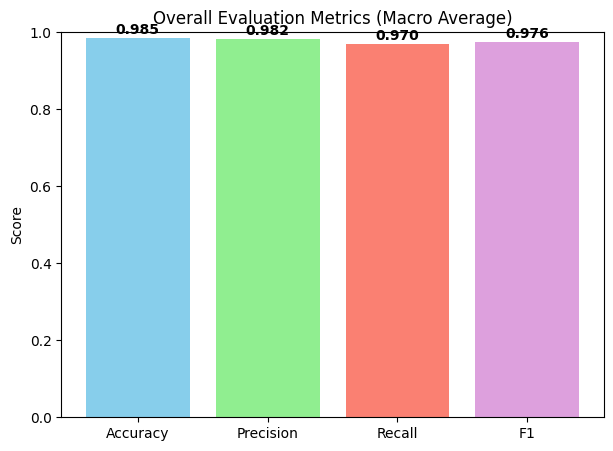

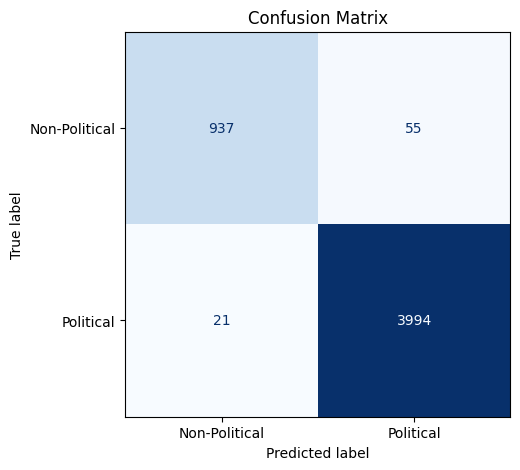

<Figure size 600x400 with 0 Axes>

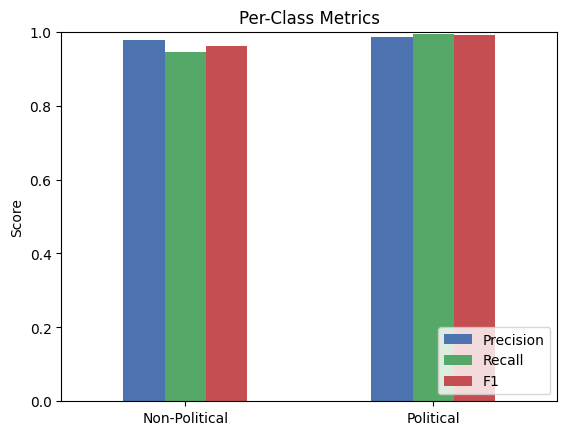

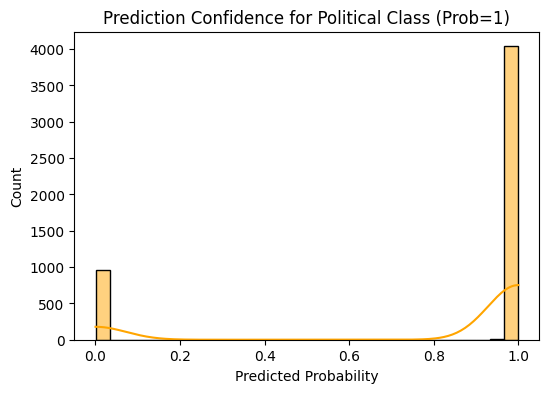

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- assuming you already have these from Trainer output ---
# y_true = eval_results.label_ids
# y_pred = np.argmax(eval_results.predictions, axis=-1)
# probs = torch.softmax(torch.tensor(eval_results.predictions), dim=1).numpy()

# ---- 1️⃣ Summary metrics bar chart ----
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics_summary = {
    "Accuracy": accuracy_score(y_true, y_pred),
    "Precision": precision_score(y_true, y_pred, average='macro'),
    "Recall": recall_score(y_true, y_pred, average='macro'),
    "F1": f1_score(y_true, y_pred, average='macro')
}

plt.figure(figsize=(7, 5))
plt.bar(metrics_summary.keys(), metrics_summary.values(), color=['skyblue', 'lightgreen', 'salmon', 'plum'])
plt.ylim(0, 1)
plt.title("Overall Evaluation Metrics (Macro Average)")
plt.ylabel("Score")
for i, v in enumerate(metrics_summary.values()):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')
plt.show()

# ---- 2️⃣ Confusion Matrix ----
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Political", "Political"])
fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix")
plt.show()

# ---- 3️⃣ Per-class precision / recall / f1 ----
report = classification_report(y_true, y_pred, target_names=["Non-Political", "Political"], output_dict=True)
per_class_df = pd.DataFrame(report).T.iloc[:2, :3]  # keep only classes, not avg rows

plt.figure(figsize=(6,4))
per_class_df.plot(kind='bar', color=['#4c72b0','#55a868','#c44e52'])
plt.ylim(0,1)
plt.title("Per-Class Metrics")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(["Precision","Recall","F1"], loc="lower right")
plt.show()

# ---- 4️⃣ Prediction confidence histogram ----
plt.figure(figsize=(6,4))
sns.histplot(probs[:,1], bins=30, kde=True, color="orange")
plt.title("Prediction Confidence for Political Class (Prob=1)")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.show()


## 8. Load Checkpoint & Generate Test Reports

Load a specific checkpoint and evaluate it on the test dataset with comprehensive reports.

### Load Specific Checkpoint

In [ ]:
# Specify checkpoint path
CHECKPOINT_PATH = '/content/drive/MyDrive/potrika dataset/experiments-model/higher_lr/checkpoint-3000'

print(f"📂 Loading checkpoint from: {CHECKPOINT_PATH}")
print("="*80)

# Load model and tokenizer from checkpoint
checkpoint_model = AutoModelForSequenceClassification.from_pretrained(CHECKPOINT_PATH)
checkpoint_tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT_PATH)

# Move model to evaluation mode
checkpoint_model.eval()

# If GPU is available, move model to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint_model = checkpoint_model.to(device)

print(f"✅ Checkpoint loaded successfully!")
print(f"   Device: {device}")
print(f"   Model: {checkpoint_model.config.model_type}")
print(f"   Number of parameters: {sum(p.numel() for p in checkpoint_model.parameters()):,}")
print("="*80)

### Evaluate on Test Dataset

In [ ]:
# Load test dataset
print("📊 Loading test dataset...")
test_dataset = tokenized['test']
print(f"Test dataset size: {len(test_dataset)}")

# Create data collator
data_collator_test = DataCollatorWithPadding(tokenizer=checkpoint_tokenizer, padding='longest', return_tensors='pt')

# Create Trainer for evaluation
from transformers import Trainer

eval_trainer = Trainer(
    model=checkpoint_model,
    args=TrainingArguments(
        output_dir='./temp_eval',
        per_device_eval_batch_size=16,
        report_to="none"
    ),
    tokenizer=checkpoint_tokenizer,
    data_collator=data_collator_test,
    compute_metrics=compute_metrics
)

print("\n🔍 Running evaluation on test dataset...")
print("="*80)

# Get predictions
test_predictions = eval_trainer.predict(test_dataset)

# Extract predictions and labels
test_logits = test_predictions.predictions
test_labels = test_predictions.label_ids
test_preds = np.argmax(test_logits, axis=-1)

# Compute probabilities
test_probs = torch.softmax(torch.tensor(test_logits), dim=1).numpy()

# Compute metrics
test_metrics = compute_metrics((test_logits, test_labels))

print("\n✅ Evaluation completed!")
print("="*80)
print("\n📈 Test Set Metrics:")
print(f"   Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"   F1 Score:  {test_metrics['f1_macro']:.4f}")
print(f"   Precision: {test_metrics['precision_macro']:.4f}")
print(f"   Recall:    {test_metrics['recall_macro']:.4f}")
print("="*80)

### Detailed Classification Report

In [ ]:
# Generate detailed classification report
from sklearn.metrics import classification_report, confusion_matrix

print("\n📊 DETAILED CLASSIFICATION REPORT")
print("="*80)
print("\nPer-Class Metrics:")
print("-"*80)

class_names = ["Non-Political", "Political"]
report = classification_report(test_labels, test_preds, target_names=class_names, digits=4)
print(report)

# Get report as dictionary for visualization
report_dict = classification_report(test_labels, test_preds, target_names=class_names, output_dict=True)

# Display as DataFrame
report_df = pd.DataFrame(report_dict).T
print("\n📈 Metrics Summary Table:")
display(report_df)

# Confusion Matrix
print("\n🔢 CONFUSION MATRIX")
print("="*80)
cm = confusion_matrix(test_labels, test_preds)
print(cm)
print("\nInterpretation:")
print(f"   True Negatives  (Non-Political correctly predicted): {cm[0,0]}")
print(f"   False Positives (Non-Political predicted as Political): {cm[0,1]}")
print(f"   False Negatives (Political predicted as Non-Political): {cm[1,0]}")
print(f"   True Positives  (Political correctly predicted): {cm[1,1]}")

# Calculate additional metrics
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
balanced_accuracy = (specificity + sensitivity) / 2

print(f"\n📊 Additional Metrics:")
print(f"   Specificity (Non-Political recall): {specificity:.4f}")
print(f"   Sensitivity (Political recall): {sensitivity:.4f}")
print(f"   Balanced Accuracy: {balanced_accuracy:.4f}")
print("="*80)

### Visualize Test Results

In [ ]:
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Metrics Bar Chart
ax1 = axes[0, 0]
metrics_dict = {
    'Accuracy': test_metrics['accuracy'],
    'F1 Score': test_metrics['f1_macro'],
    'Precision': test_metrics['precision_macro'],
    'Recall': test_metrics['recall_macro']
}
bars = ax1.bar(metrics_dict.keys(), metrics_dict.values(), color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
ax1.set_ylim(0, 1)
ax1.set_ylabel('Score')
ax1.set_title('Overall Test Metrics', fontweight='bold', fontsize=12)
ax1.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

# 2. Confusion Matrix Heatmap
ax2 = axes[0, 1]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2, 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
ax2.set_title('Confusion Matrix', fontweight='bold', fontsize=12)
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')

# 3. Per-Class Performance
ax3 = axes[0, 2]
per_class_metrics = report_df.iloc[:2, :3]  # Get only class rows and first 3 columns
x = np.arange(len(class_names))
width = 0.25
bars1 = ax3.bar(x - width, per_class_metrics['precision'], width, label='Precision', color='#3498db')
bars2 = ax3.bar(x, per_class_metrics['recall'], width, label='Recall', color='#2ecc71')
bars3 = ax3.bar(x + width, per_class_metrics['f1-score'], width, label='F1-Score', color='#e74c3c')
ax3.set_ylabel('Score')
ax3.set_title('Per-Class Metrics Comparison', fontweight='bold', fontsize=12)
ax3.set_xticks(x)
ax3.set_xticklabels(class_names)
ax3.legend()
ax3.set_ylim(0, 1)
ax3.grid(axis='y', alpha=0.3)

# 4. Prediction Confidence Distribution
ax4 = axes[1, 0]
ax4.hist([test_probs[test_labels==0][:, 0], test_probs[test_labels==1][:, 1]], 
         bins=30, label=['Non-Political (True)', 'Political (True)'], 
         color=['skyblue', 'salmon'], alpha=0.7)
ax4.set_xlabel('Prediction Confidence')
ax4.set_ylabel('Frequency')
ax4.set_title('Prediction Confidence Distribution', fontweight='bold', fontsize=12)
ax4.legend()
ax4.grid(alpha=0.3)

# 5. ROC-like visualization (Confidence for each class)
ax5 = axes[1, 1]
for i, class_name in enumerate(class_names):
    class_probs = test_probs[test_labels == i, i]
    ax5.hist(class_probs, bins=30, alpha=0.6, label=f'{class_name} (n={len(class_probs)})')
ax5.set_xlabel('Confidence Score')
ax5.set_ylabel('Count')
ax5.set_title('Confidence Score Distribution by True Class', fontweight='bold', fontsize=12)
ax5.legend()
ax5.grid(alpha=0.3)

# 6. Prediction Correctness
ax6 = axes[1, 2]
correct = (test_preds == test_labels).sum()
incorrect = len(test_labels) - correct
ax6.pie([correct, incorrect], labels=['Correct', 'Incorrect'], 
        autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
ax6.set_title(f'Prediction Correctness\n({correct}/{len(test_labels)} correct)', 
             fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print("✅ Visualizations generated successfully!")

### Save Test Predictions with Original Text

In [ ]:
# Reload original data to get text
print("📝 Preparing detailed predictions CSV...")

# Load original CSV
df_original_full = pd.read_csv(csv_path)
df_original_full['label'] = df_original_full['label'].astype(int)

# Recreate the same test split
df_train_val_temp, df_test_temp = train_test_split(
    df_original_full, test_size=TEST_SIZE, stratify=df_original_full['label'], random_state=RANDOM_SEED
)

# Reset index to match test_dataset
df_test_with_text = df_test_temp.reset_index(drop=True).copy()

# Add predictions
df_test_with_text['predicted_label'] = test_preds
df_test_with_text['true_label'] = test_labels
df_test_with_text['prediction_correct'] = (test_preds == test_labels)

# Add probabilities
df_test_with_text['prob_non_political'] = test_probs[:, 0]
df_test_with_text['prob_political'] = test_probs[:, 1]
df_test_with_text['confidence'] = test_probs.max(axis=1)

# Add prediction labels as text
label_map = {0: "Non-Political", 1: "Political"}
df_test_with_text['predicted_label_text'] = df_test_with_text['predicted_label'].map(label_map)
df_test_with_text['true_label_text'] = df_test_with_text['true_label'].map(label_map)

# Identify misclassifications
df_test_with_text['misclassified'] = ~df_test_with_text['prediction_correct']

# Save to CSV
output_path = os.path.join(os.path.dirname(CHECKPOINT_PATH), 'test_predictions_detailed.csv')
df_test_with_text.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"✅ Detailed predictions saved to: {output_path}")
print(f"\n📊 Predictions Summary:")
print(f"   Total samples: {len(df_test_with_text)}")
print(f"   Correct predictions: {df_test_with_text['prediction_correct'].sum()} ({df_test_with_text['prediction_correct'].mean()*100:.2f}%)")
print(f"   Misclassifications: {df_test_with_text['misclassified'].sum()} ({df_test_with_text['misclassified'].mean()*100:.2f}%)")
print(f"\n📂 File columns: {list(df_test_with_text.columns)}")

# Show sample of predictions
print("\n📋 Sample Predictions (first 5 rows):")
display(df_test_with_text[['text', 'true_label_text', 'predicted_label_text', 
                           'prediction_correct', 'confidence']].head())

### Generate Final Summary Report

In [ ]:
# Generate comprehensive summary report
print("\n" + "="*80)
print("📊 FINAL TEST EVALUATION SUMMARY REPORT")
print("="*80)

print(f"\n🔧 Model Information:")
print(f"   Checkpoint: {CHECKPOINT_PATH}")
print(f"   Model Type: {checkpoint_model.config.model_type}")
print(f"   Parameters: {sum(p.numel() for p in checkpoint_model.parameters()):,}")

print(f"\n📁 Dataset Information:")
print(f"   Test Set Size: {len(test_dataset)}")
print(f"   Class Distribution:")
print(f"      Non-Political: {(test_labels == 0).sum()} ({(test_labels == 0).mean()*100:.2f}%)")
print(f"      Political: {(test_labels == 1).sum()} ({(test_labels == 1).mean()*100:.2f}%)")

print(f"\n🎯 Overall Performance Metrics:")
print(f"   Accuracy:  {test_metrics['accuracy']:.4f} ({test_metrics['accuracy']*100:.2f}%)")
print(f"   F1 Score:  {test_metrics['f1_macro']:.4f}")
print(f"   Precision: {test_metrics['precision_macro']:.4f}")
print(f"   Recall:    {test_metrics['recall_macro']:.4f}")

print(f"\n📊 Per-Class Performance:")
for i, class_name in enumerate(class_names):
    class_precision = report_dict[class_name]['precision']
    class_recall = report_dict[class_name]['recall']
    class_f1 = report_dict[class_name]['f1-score']
    class_support = report_dict[class_name]['support']
    
    print(f"\n   {class_name}:")
    print(f"      Precision: {class_precision:.4f}")
    print(f"      Recall:    {class_recall:.4f}")
    print(f"      F1-Score:  {class_f1:.4f}")
    print(f"      Support:   {class_support}")

print(f"\n🔢 Confusion Matrix Analysis:")
print(f"   True Negatives:  {cm[0,0]:>6} (Correct Non-Political)")
print(f"   False Positives: {cm[0,1]:>6} (Non-Political misclassified as Political)")
print(f"   False Negatives: {cm[1,0]:>6} (Political misclassified as Non-Political)")
print(f"   True Positives:  {cm[1,1]:>6} (Correct Political)")

print(f"\n📈 Additional Statistics:")
print(f"   Specificity: {specificity:.4f}")
print(f"   Sensitivity: {sensitivity:.4f}")
print(f"   Balanced Accuracy: {balanced_accuracy:.4f}")
print(f"   Error Rate: {(1 - test_metrics['accuracy']):.4f} ({(1 - test_metrics['accuracy'])*100:.2f}%)")

print(f"\n💾 Output Files:")
print(f"   Predictions CSV: {output_path}")

print("\n" + "="*80)
print("✅ EVALUATION COMPLETE!")
print("="*80)

# Save summary report as text file
report_text_path = os.path.join(os.path.dirname(CHECKPOINT_PATH), 'test_evaluation_report.txt')
with open(report_text_path, 'w', encoding='utf-8') as f:
    f.write("="*80 + "\n")
    f.write("BANGLA NEWS CLASSIFICATION - TEST EVALUATION REPORT\n")
    f.write("="*80 + "\n\n")
    f.write(f"Checkpoint: {CHECKPOINT_PATH}\n")
    f.write(f"Test Set Size: {len(test_dataset)}\n\n")
    f.write("Overall Metrics:\n")
    f.write(f"  Accuracy:  {test_metrics['accuracy']:.4f}\n")
    f.write(f"  F1 Score:  {test_metrics['f1_macro']:.4f}\n")
    f.write(f"  Precision: {test_metrics['precision_macro']:.4f}\n")
    f.write(f"  Recall:    {test_metrics['recall_macro']:.4f}\n\n")
    f.write("Classification Report:\n")
    f.write(report + "\n")
    f.write(f"\nConfusion Matrix:\n{cm}\n")

print(f"\n📄 Text report saved to: {report_text_path}")

---

## 📝 Summary & Next Steps

### How to Use This Notebook:

1. **Setup**: Run cells in Section 1 to install dependencies and import libraries
2. **Data Exploration**: Section 2 provides insights into your dataset
3. **Preprocessing**: Section 3 prepares and tokenizes data
4. **Training**: Section 4 allows you to:
   - Configure multiple hyperparameter settings
   - Train models with different configurations
   - Compare results automatically
5. **Analysis**: Sections 5-7 provide detailed analysis and visualizations

### Hyperparameter Experimentation:

The notebook includes 5 pre-configured experiments:
- **baseline**: Standard configuration for quick testing
- **higher_lr**: Recommended configuration with good balance
- **larger_batch**: For systems with more GPU memory
- **aggressive_regularization**: To prevent overfitting
- **fast_convergence**: Experimental high learning rate

You can enable/disable experiments by modifying the `configs_to_train` dictionary.

### Adding Custom Configurations:

To add your own hyperparameter configuration:
1. Add a new entry to `hyperparameter_configs` dictionary
2. Enable it in `configs_to_train`
3. Run the training cell

### Key Hyperparameters to Experiment With:

- **Learning Rate**: [1e-5, 2e-5, 3e-5, 5e-5, 1e-4]
- **Batch Size**: [4, 8, 16, 32]
- **Scheduler**: ['linear', 'cosine', 'polynomial', 'constant']
- **Weight Decay**: [0.0, 0.01, 0.05, 0.1]
- **Warmup Ratio**: [0.0, 0.05, 0.1, 0.15]
- **Epochs**: [3, 5, 7, 10]